# Notebook 12 — Neighborhood Risk Ranking with 511 Features

## Objective
This notebook predicts **next-day neighborhood collision risk** using local collision history, weather, spatial disruption features, and the **citywide surge probability** from Notebook 11 as a global tide feature.

Unlike Notebook 11, which modeled a citywide target, this notebook evaluates whether localized construction and disruption signals improve **neighborhood-level ranking performance**.

## Prediction Task
For each neighborhood-day at date `t`, predict whether the neighborhood will experience **at least one collision on date `t+1`**.

## Main Evaluation Question
If we flag the **top K highest-risk neighborhoods today**, how many of them actually experience a collision tomorrow?

Primary metric:
- Precision@K

Secondary metrics:
- Recall@K
- PR-AUC
- ROC-AUC

### Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

import matplotlib.pyplot as plt
import seaborn as sns

### Paths and load data

In [2]:
BASE_DIR = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

FEATURES_PATH = BASE_DIR / "data" / "processed" / "features_nbhd_day_511.parquet"
CITYWISE_PRED_PATH = BASE_DIR / "data" / "processed" / "pred_citywide_surge_511.parquet"

print("FEATURES_PATH exists:", FEATURES_PATH.exists(), "->", FEATURES_PATH)
print("CITYWISE_PRED_PATH exists:", CITYWISE_PRED_PATH.exists(), "->", CITYWISE_PRED_PATH)

df = pd.read_parquet(FEATURES_PATH)
city_df = pd.read_parquet(CITYWISE_PRED_PATH)

print("Neighborhood feature table:", df.shape)
print("Citywide prediction table:", city_df.shape)

display(df.head())
display(city_df.head())

FEATURES_PATH exists: True -> C:\code\pyspark-playground\Covercheck-Toronto\data\processed\features_nbhd_day_511.parquet
CITYWISE_PRED_PATH exists: True -> C:\code\pyspark-playground\Covercheck-Toronto\data\processed\pred_citywide_surge_511.parquet
Neighborhood feature table: (691408, 114)
Citywide prediction table: (1460, 4)


,area_id,area_name,date,collisions,nbhd_id,ksi_collisions,ksi_fatal_collisions,ksi_serious_collisions,ksi_fatal_victims,ksi_victim_count,...,road_construction_severity_weighted_halo_lag7,road_construction_severity_weighted_halo_roll7_sum,road_construction_severity_weighted_halo_roll14_sum,road_construction_full_closure_count_halo_lag1,road_construction_full_closure_count_halo_lag7,road_construction_full_closure_count_halo_roll7_sum,road_construction_full_closure_count_halo_roll14_sum,dow,month,year
0,2502213,West Humber-Clairville,2014-01-08,1,1,0,0,0,0,0,...,0.0,0.0,NaN,0.0,0.0,0.0,NaN,2,1,2014
1,2502213,West Humber-Clairville,2014-01-09,4,1,0,0,0,0,0,...,0.0,0.0,NaN,0.0,0.0,0.0,NaN,3,1,2014
2,2502213,West Humber-Clairville,2014-01-10,3,1,0,0,0,0,0,...,0.0,0.0,NaN,0.0,0.0,0.0,NaN,4,1,2014
3,2502213,West Humber-Clairville,2014-01-11,2,1,0,0,0,0,0,...,0.0,0.0,NaN,0.0,0.0,0.0,NaN,5,1,2014
4,2502213,West Humber-Clairville,2014-01-12,0,1,0,0,0,0,0,...,0.0,0.0,NaN,0.0,0.0,0.0,NaN,6,1,2014


,date,target_surge_tomorrow,y_true,surge_proba
0,2024-01-01,92.0,0,0.013979
1,2024-01-02,122.0,0,0.063762
2,2024-01-03,140.0,0,0.021278
3,2024-01-04,108.0,0,0.117656
4,2024-01-05,203.0,0,0.012603


### Keep only needed citywide columns and merge

In [3]:
# Keep only the citywide tide feature needed for Notebook 12
city_df = city_df[["date", "surge_proba"]].copy()

city_df["date"] = pd.to_datetime(city_df["date"])
df["date"] = pd.to_datetime(df["date"])

print("Feature date range:", df["date"].min(), "to", df["date"].max())
print("Citywide prediction date range:", city_df["date"].min(), "to", city_df["date"].max())

# IMPORTANT: Notebook 11 prediction file contains duplicated dates because it combines
# multiple evaluation runs. Collapse to one row per date before merging.
dup_dates = city_df["date"].duplicated().sum()
print("Duplicated dates in city_df before fix:", dup_dates)

city_df = (
    city_df.groupby("date", as_index=False)["surge_proba"]
    .mean()
    .sort_values("date")
)

print("Rows in city_df after date dedup:", city_df.shape)
print("Duplicated dates in city_df after fix:", city_df["date"].duplicated().sum())

rows_before_merge = len(df)

df = df.merge(city_df, on="date", how="left")

print("Rows before merge:", rows_before_merge)
print("Rows after merge:", len(df))
print("Missing surge_proba:", df["surge_proba"].isna().sum())
print("Non-missing surge_proba:", df["surge_proba"].notna().sum())

assert len(df) == rows_before_merge, "Merge changed row count — check duplicate dates in city_df."

Feature date range: 2014-01-08 00:00:00 to 2025-12-31 00:00:00
Citywide prediction date range: 2024-01-01 00:00:00 to 2025-12-30 00:00:00
Duplicated dates in city_df before fix: 730
Rows in city_df after date dedup: (730, 2)
Duplicated dates in city_df after fix: 0
Rows before merge: 691408
Rows after merge: 691408
Missing surge_proba: 576068
Non-missing surge_proba: 115340


### Interpretation: Citywide "Tide" Integration

#### We merge `surge_proba` from Notebook 11 as a candidate **global tide** feature.

#### The idea is that while Notebook 12 focuses on **where** risk is located, the citywide probability may provide context about how much overall collision pressure exists in the system on a given day.

#### This is treated as an experimental global-context feature whose empirical contribution will be evaluated later through feature importance.

### filling the missing surge_proba with a neutral fallback

In [4]:
# Notebook 11 only saved citywide predictions for test dates (2024+).
# For earlier rows, use a neutral fallback so the model can still train.
df["surge_proba"] = df["surge_proba"].fillna(df["surge_proba"].median())

print("Missing surge_proba after fill:", df["surge_proba"].isna().sum())
print("Filled surge_proba median:", df["surge_proba"].median())

Missing surge_proba after fill: 0
Filled surge_proba median: 0.10989214804758085


### Create next-day neighborhood target

In [5]:
df = df.sort_values(["nbhd_id", "date"]).reset_index(drop=True)

df["collisions_tomorrow"] = df.groupby("nbhd_id")["collisions"].shift(-1)
df["target_collision_tomorrow"] = (df["collisions_tomorrow"].fillna(0) >= 1).astype(int)

# drop final date per neighborhood where tomorrow is unavailable
df = df[df["collisions_tomorrow"].notna()].copy()

print(df[["date", "nbhd_id", "collisions", "collisions_tomorrow", "target_collision_tomorrow"]].head(10))
print("Positive rate:", df["target_collision_tomorrow"].mean())

        date  nbhd_id  collisions  collisions_tomorrow  \
0 2014-01-08        1           1                  4.0   
1 2014-01-09        1           4                  3.0   
2 2014-01-10        1           3                  2.0   
3 2014-01-11        1           2                  0.0   
4 2014-01-12        1           0                  1.0   
5 2014-01-13        1           1                  2.0   
6 2014-01-14        1           2                  2.0   
7 2014-01-15        1           2                  4.0   
8 2014-01-16        1           4                  2.0   
9 2014-01-17        1           2                  1.0   

   target_collision_tomorrow  
0                          1  
1                          1  
2                          1  
3                          0  
4                          1  
5                          1  
6                          1  
7                          1  
8                          1  
9                          1  
Positive rate: 0.523

### post-merge validation cell

In [6]:
print("Unique dates in df:", df["date"].nunique())
print("Unique neighborhoods:", df["nbhd_id"].nunique())
print("Expected neighborhood-days if no duplication:", df["date"].nunique() * df["nbhd_id"].nunique())
print("Actual rows:", len(df))

Unique dates in df: 4375
Unique neighborhoods: 158
Expected neighborhood-days if no duplication: 691250
Actual rows: 691250


### Feature selection

In [7]:
# Exclude identifiers, targets, and known leakage / non-numeric fields
drop_cols = {
    # identifiers / names / geometry
    "date",
    "nbhd_id",
    "area_id",
    "AREA_ID",
    "area_name",
    "AREA_NAME",
    "geometry",

    # future / target columns
    "collisions_tomorrow",
    "target_collision_tomorrow",

    # same-day direct leakage
    "collisions",
    "city_collisions",

    # same-day severity leakage
    "ksi_collisions",
    "ksi_weighted_score",
    "ksi_fatal_collisions",
    "ksi_serious_collisions",
    "ksi_fatal_victims",
    "ksi_victim_count",

    # in case older versions exist
    "ksi_count",
    "ksi_weighted"
}

feature_cols = [c for c in df.columns if c not in drop_cols]

# Safety check: LightGBM needs numeric / bool columns only
bad_dtype_cols = df[feature_cols].select_dtypes(exclude=["number", "bool"]).columns.tolist()

print("Number of features:", len(feature_cols))
print("First 40 features:", feature_cols[:40])
print("Non-numeric feature columns still present:", bad_dtype_cols)

assert len(bad_dtype_cols) == 0, f"Remove or encode these non-numeric columns before training: {bad_dtype_cols}"

Number of features: 104
First 40 features: ['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd', 'freeze_day', 'snow_day', 'rain_day', 'road_events_count', 'road_events_severity_weighted', 'road_events_full_closure_count', 'road_construction_count', 'road_construction_severity_weighted', 'road_construction_full_closure_count', 'collisions_lag1', 'collisions_lag7', 'collisions_lag14', 'ksi_collisions_lag1', 'ksi_collisions_lag7', 'ksi_collisions_lag14', 'ksi_weighted_score_lag1', 'ksi_weighted_score_lag7', 'ksi_weighted_score_lag14', 'road_events_count_lag1', 'road_events_count_lag7', 'road_events_count_lag14', 'road_events_severity_weighted_lag1', 'road_events_severity_weighted_lag7', 'road_events_severity_weighted_lag14', 'road_events_full_closure_count_lag1', 'road_events_full_closure_count_lag7', 'road_events_full_closure_count_lag14', 'road_construction_count_lag1', 'road_construction_count_lag7', 'road_construction_count_lag14', 'road_construction_severity_weighted_lag1', 'road_constru

### Interpretation: Leakage Control
#### To maintain forecasting integrity, we exclude same-day realized neighborhood collision totals and direct target-like severity columns from the feature matrix.

#### This notebook should be interpreted as an **end-of-day next-day neighborhood forecast**:

#### - features from date `t`
#### - target outcome on date `t+1`

#### This means the model can use weather and disruption conditions observed by the end of day `t`, but it does **not** use the realized neighborhood collision count from day `t` in the strict model.

### Train/test split

In [8]:
split_date_full = pd.Timestamp("2024-01-01")
df_full = df.copy()

train_full = df_full[df_full["date"] < split_date_full].copy()
test_full  = df_full[df_full["date"] >= split_date_full].copy()

print("FULL HISTORY SPLIT")
print("Train rows:", train_full.shape)
print("Test rows:", test_full.shape)
print("Train date range:", train_full["date"].min(), "to", train_full["date"].max())
print("Test date range:", test_full["date"].min(), "to", test_full["date"].max())

FULL HISTORY SPLIT
Train rows: (575910, 117)
Test rows: (115340, 117)
Train date range: 2014-01-08 00:00:00 to 2023-12-31 00:00:00
Test date range: 2024-01-01 00:00:00 to 2025-12-30 00:00:00


### Build X/y

In [9]:
X_train = train_full[feature_cols].copy()
y_train = train_full["target_collision_tomorrow"].copy()

X_test = test_full[feature_cols].copy()
y_test = test_full["target_collision_tomorrow"].copy()

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

(575910, 104) (575910,) (115340, 104) (115340,)
Train positive rate: 0.519395391641055
Test positive rate: 0.5442604473729842


#### Modeling Strategy: Strict vs. End-of-Day Enhanced
#### We are evaluating two versions of the neighborhood model:
#### - **Strict Forecasting (Baseline):** excludes same-day realized neighborhood collision counts, while still allowing end-of-day weather and disruption conditions from date `t`.
#### - **End-of-Day Enhanced:** additionally includes same-day realized neighborhood collisions for midnight operational planning.
#### Note on Disruption: While we expect localized 511 features to have higher importance here than in the citywide model, they are competing with powerful auto-regressive signals like collisions_lag1 and the "Global Tide" (surge_proba).

### Strict vs End-of-Day Enhanced comparison (REAL comparison)

In [10]:

target_col = "target_collision_tomorrow"

# Strict = no same-day realized neighborhood collisions
feature_cols_strict = feature_cols.copy()

# Enhanced = include same-day realized neighborhood collisions
feature_cols_enhanced = feature_cols.copy() + ["collisions"]

X_train_strict = train_full[feature_cols_strict].copy()
X_test_strict  = test_full[feature_cols_strict].copy()

X_train_enh = train_full[feature_cols_enhanced].copy()
X_test_enh  = test_full[feature_cols_enhanced].copy()

y_train = train_full[target_col].copy()
y_test  = test_full[target_col].copy()

model_strict = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight="balanced",
    verbose=-1
)

model_enhanced = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight="balanced",
    verbose=-1
)

model_strict.fit(X_train_strict, y_train)
model_enhanced.fit(X_train_enh, y_train)

test_full = test_full.copy()
test_full["risk_proba_strict"] = model_strict.predict_proba(X_test_strict)[:, 1]
test_full["risk_proba_enhanced"] = model_enhanced.predict_proba(X_test_enh)[:, 1]

comparison_metrics = pd.DataFrame([
    {
        "model_version": "strict",
        "roc_auc": roc_auc_score(y_test, test_full["risk_proba_strict"]),
        "pr_auc": average_precision_score(y_test, test_full["risk_proba_strict"]),
        "brier": brier_score_loss(y_test, test_full["risk_proba_strict"]),
        "n_features": len(feature_cols_strict)
    },
    {
        "model_version": "enhanced",
        "roc_auc": roc_auc_score(y_test, test_full["risk_proba_enhanced"]),
        "pr_auc": average_precision_score(y_test, test_full["risk_proba_enhanced"]),
        "brier": brier_score_loss(y_test, test_full["risk_proba_enhanced"]),
        "n_features": len(feature_cols_enhanced)
    }
])

display(comparison_metrics)

,model_version,roc_auc,pr_auc,brier,n_features
0,strict,0.718062,0.758727,0.212353,104
1,enhanced,0.718957,0.759533,0.212070,105


### Choose one primary model explicitly

In [11]:
# Choose the primary model for the rest of the notebook
PRIMARY_MODEL = "strict"   # change to "enhanced" if you want that as the official version

if PRIMARY_MODEL == "strict":
    model_primary = model_strict
    primary_feature_cols = feature_cols_strict
    test_full["risk_proba"] = test_full["risk_proba_strict"]
elif PRIMARY_MODEL == "enhanced":
    model_primary = model_enhanced
    primary_feature_cols = feature_cols_enhanced
    test_full["risk_proba"] = test_full["risk_proba_enhanced"]
else:
    raise ValueError("PRIMARY_MODEL must be either 'strict' or 'enhanced'")

print("Primary model selected:", PRIMARY_MODEL)
print("Primary feature count:", len(primary_feature_cols))

Primary model selected: strict
Primary feature count: 104


### Precision@K and Recall@K functions

In [12]:
def precision_recall_at_k(df_pred, k=10):
    """
    Evaluates ranking quality day by day.
    For each date, sort neighborhoods by predicted risk and keep top-k.
    """
    daily_scores = []

    for dt, g in df_pred.groupby("date"):
        g = g.sort_values("risk_proba", ascending=False).head(k).copy()

        hits = g["target_collision_tomorrow"].sum()
        actual_positives = df_pred.loc[df_pred["date"] == dt, "target_collision_tomorrow"].sum()

        precision_k = hits / k if k > 0 else np.nan
        recall_k = hits / actual_positives if actual_positives > 0 else np.nan

        daily_scores.append({
            "date": dt,
            "k": k,
            "hits": hits,
            "actual_positives": actual_positives,
            "precision_at_k": precision_k,
            "recall_at_k": recall_k
        })

    out = pd.DataFrame(daily_scores)

    return out, {
        "K": k,
        "Mean_Precision@K": out["precision_at_k"].mean(),
        "Mean_Recall@K": out["recall_at_k"].mean()
    }

### side-by-side ranking comparison for strict vs enhanced

In [13]:
def summarize_ranking_for_score(df_pred, score_col, ks=(5, 10, 15)):
    rows = []
    temp = df_pred[["date", "nbhd_id", "target_collision_tomorrow", score_col]].copy()
    temp = temp.rename(columns={score_col: "risk_proba"})

    for k in ks:
        _, summary = precision_recall_at_k(temp, k=k)
        rows.append({
            "model_score": score_col,
            "K": k,
            "Mean_Precision@K": summary["Mean_Precision@K"],
            "Mean_Recall@K": summary["Mean_Recall@K"]
        })

    return pd.DataFrame(rows)

strict_rank_summary = summarize_ranking_for_score(test_full, "risk_proba_strict")
enh_rank_summary = summarize_ranking_for_score(test_full, "risk_proba_enhanced")

ranking_comparison = pd.concat([strict_rank_summary, enh_rank_summary], ignore_index=True)
display(ranking_comparison)

,model_score,K,Mean_Precision@K,Mean_Recall@K
0,risk_proba_strict,5,0.937260,0.055334
1,risk_proba_strict,10,0.909589,0.107285
2,risk_proba_strict,15,0.885571,0.156464
3,risk_proba_enhanced,5,0.938630,0.055449
4,risk_proba_enhanced,10,0.905479,0.106686
5,risk_proba_enhanced,15,0.886667,0.156534


### side-by-side comparison chart for strict vs enhanced PR-AUC and Precision@10

In [14]:
comparison_plot_df = ranking_comparison[ranking_comparison["K"] == 10].copy()

comparison_plot_df["model_version"] = comparison_plot_df["model_score"].map({
    "risk_proba_strict": "strict",
    "risk_proba_enhanced": "enhanced"
})

comparison_plot_df = comparison_plot_df.merge(
    comparison_metrics[["model_version", "pr_auc", "roc_auc", "brier"]],
    on="model_version",
    how="left"
)

display(comparison_plot_df)

,model_score,K,Mean_Precision@K,Mean_Recall@K,model_version,pr_auc,roc_auc,brier
0,risk_proba_strict,10,0.909589,0.107285,strict,0.758727,0.718062,0.212353
1,risk_proba_enhanced,10,0.905479,0.106686,enhanced,0.759533,0.718957,0.212070


### Evaluate ranking performance

In [15]:
eval_cols = ["date", "nbhd_id", "target_collision_tomorrow", "risk_proba"]
rank_eval_df = test_full[eval_cols].copy()

p5_df, p5_summary = precision_recall_at_k(rank_eval_df, k=5)
p10_df, p10_summary = precision_recall_at_k(rank_eval_df, k=10)
p15_df, p15_summary = precision_recall_at_k(rank_eval_df, k=15)

ranking_summary = pd.DataFrame([p5_summary, p10_summary, p15_summary])
display(ranking_summary)

,K,Mean_Precision@K,Mean_Recall@K
0,5,0.937260,0.055334
1,10,0.909589,0.107285
2,15,0.885571,0.156464


#### In an operational setting, resources (police, tow trucks, or ambulances) are limited. This block iterates through different values of K to identify the "Sweet Spot" where we maximize the Lift (how many times better we are than random guessing) before precision starts to drop off significantly.

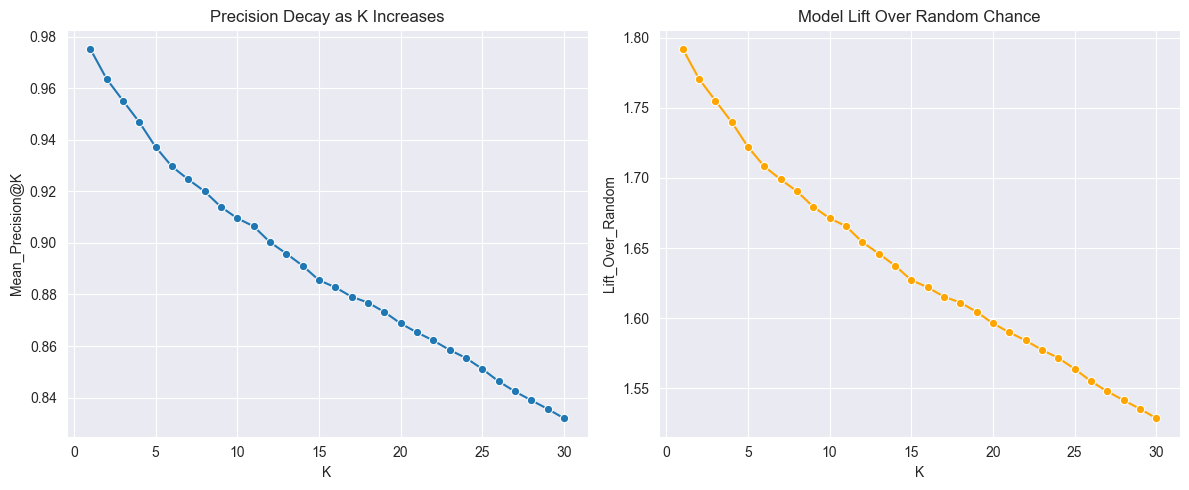

,K,Mean_Precision@K,Mean_Recall@K,Lift_Over_Random
0,1,0.975342,0.011522,1.792051
1,2,0.963699,0.022751,1.770657
2,3,0.955251,0.033876,1.755136
3,4,0.946918,0.044758,1.739825
4,5,0.937260,0.055334,1.722080


In [16]:
def automated_k_optimization(df_pred, target_col, max_k=30):
    results = []
    random_baseline = df_pred[target_col].mean()

    # Test every K from 1 to max_k
    for k in range(1, max_k + 1):
        _, summary = precision_recall_at_k(df_pred, k=k)
        summary['Lift_Over_Random'] = summary['Mean_Precision@K'] / random_baseline if random_baseline > 0 else 0
        results.append(summary)

    opt_df = pd.DataFrame(results)
    return opt_df

# Execute Optimization
optimization_results = automated_k_optimization(rank_eval_df, "target_collision_tomorrow")

# Visualization of the Sweet Spot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=optimization_results, x='K', y='Mean_Precision@K', marker='o')
plt.title("Precision Decay as K Increases")

plt.subplot(1, 2, 2)
sns.lineplot(data=optimization_results, x='K', y='Lift_Over_Random', marker='o', color='orange')
plt.title("Model Lift Over Random Chance")
plt.tight_layout()
plt.show()

display(optimization_results.sort_values('Lift_Over_Random', ascending=False).head(5))

### Feature importance

In [17]:
fi = pd.DataFrame({
    "feature": primary_feature_cols,
    "importance": model_primary.feature_importances_
}).sort_values("importance", ascending=False)

display(fi.head(25))

,feature,importance
44,collisions_roll30_sum,1205
100,dow,953
5,wspd,869
0,tavg,816
1,tmin,810
2,tmax,768
43,collisions_roll14_sum,526
102,year,521
101,month,514
3,prcp,463


### Plot top features

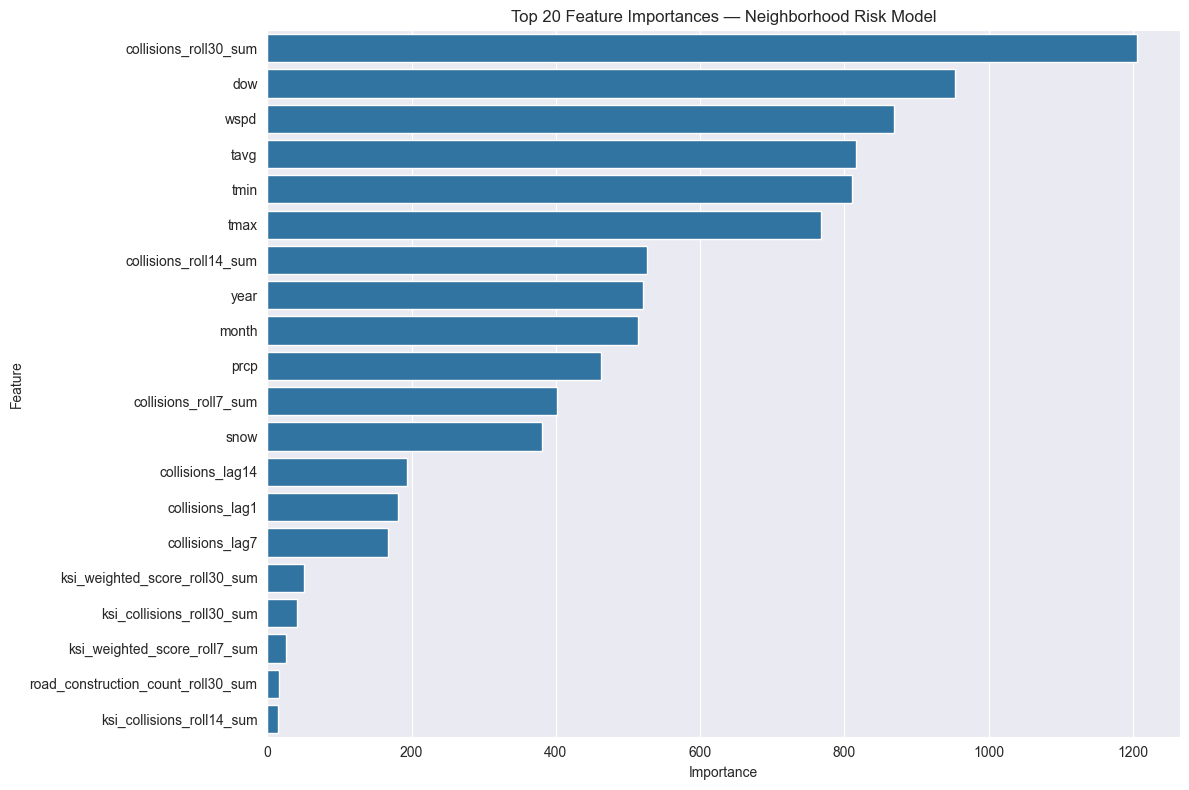

In [18]:
top_n = 20
fi_top = fi.head(top_n).copy()

plt.figure(figsize=(12, 8))
sns.barplot(data=fi_top, x="importance", y="feature")
plt.title("Top 20 Feature Importances — Neighborhood Risk Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Inspect spatial/disruption features specifically

,feature,importance
56,road_construction_count_roll30_sum,16
35,road_construction_count_lag14,6
70,road_construction_total_pressure_roll14_sum,6
66,road_construction_count_halo,4
69,road_construction_total_pressure,3
12,road_construction_count,2
67,road_construction_severity_weighted_halo,2
62,road_construction_severity_weighted_roll30_sum,2
55,road_construction_count_roll14_sum,1
95,road_construction_severity_weighted_halo_roll1...,1


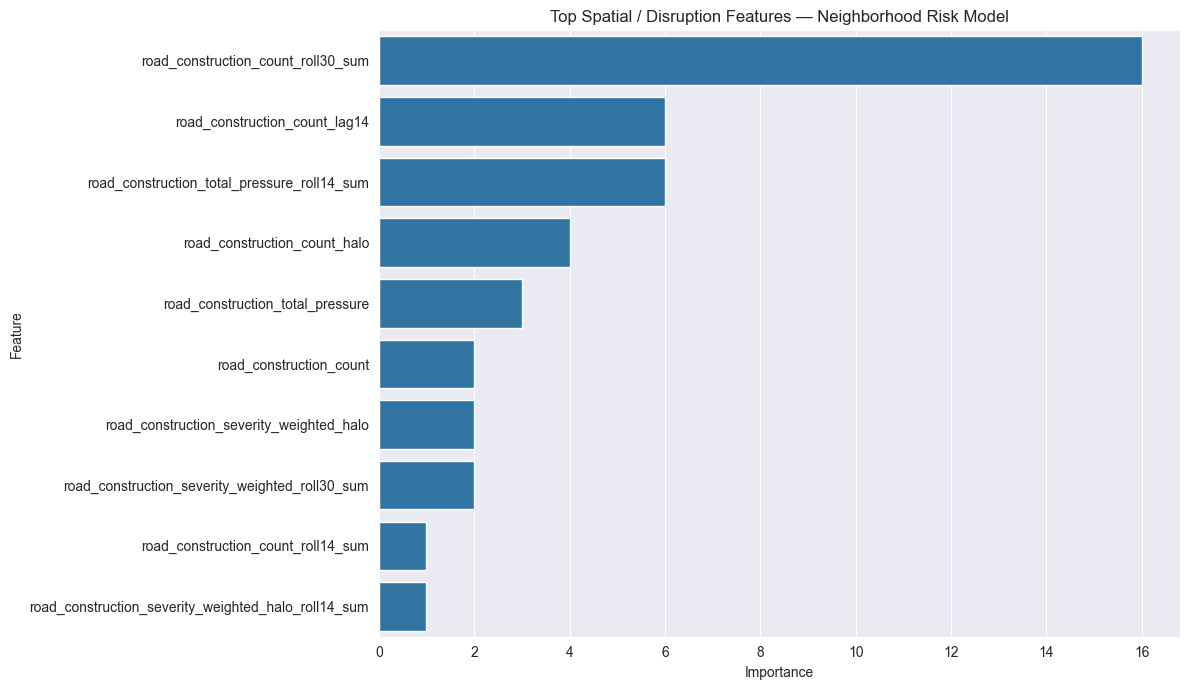

In [19]:
spatial_pattern = r"road_|halo|disrupted|pressure|construction"

fi_spatial = fi[
    fi["feature"].str.contains(spatial_pattern, case=False, na=False)
].copy()

display(fi_spatial.head(20))

fi_spatial_nonzero = fi_spatial[fi_spatial["importance"] > 0].head(15)

if not fi_spatial_nonzero.empty:
    plt.figure(figsize=(12, 7))
    sns.barplot(data=fi_spatial_nonzero, x="importance", y="feature")
    plt.title("Top Spatial / Disruption Features — Neighborhood Risk Model")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("No spatial/disruption features had positive importance.")

### Check whether the citywide tide feature matters

In [20]:
fi[fi["feature"] == "surge_proba"]

,feature,importance
103,surge_proba,0


### Interpretation: Global Tide Feature

#### In this version, `surge_proba` has zero feature importance.

#### This likely reflects two factors:

#### 1. the Notebook 11 prediction artifact only covers 2024–2025, so earlier dates required a neutral median fill;
#### 2. neighborhood-specific rolling collision baselines and calendar/weather effects already explain most of the predictive signal.

#### So the citywide tide concept remains theoretically reasonable, but it is **not yet empirically contributing** in the current implementation.

#### Performance Visualization: Precision@K
#### The chart below compares our model's precision against a random-guess baseline. This demonstrates the operational value of the ranking system: if we send resources to the Top-K neighborhoods, how often do we "hit" a real collision?

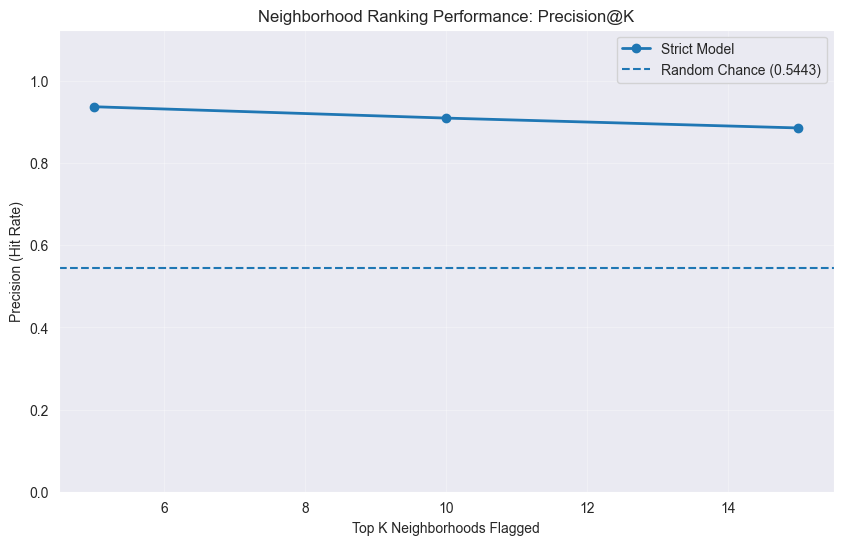

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_precision_comparison(test_df, target_name, model_label):
    random_baseline = test_df[target_name].mean()
    ks = [5, 10, 15]
    precision_vals = [
        p5_summary["Mean_Precision@K"],
        p10_summary["Mean_Precision@K"],
        p15_summary["Mean_Precision@K"]
    ]

    plt.figure(figsize=(10, 6))
    plt.plot(ks, precision_vals, marker='o', linewidth=2, label=f'{model_label} Model')
    plt.axhline(random_baseline, linestyle='--', label=f'Random Chance ({random_baseline:.4f})')
    plt.title('Neighborhood Ranking Performance: Precision@K')
    plt.xlabel('Top K Neighborhoods Flagged')
    plt.ylabel('Precision (Hit Rate)')
    plt.ylim(0, max(precision_vals) * 1.2)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_precision_comparison(test_full, "target_collision_tomorrow", PRIMARY_MODEL.capitalize())

#### Operational Health Check: Model Drift Analysis
#### 511 features (construction and closures) are highly temporal. This block compares the model's performance in the first half of the test set versus the second half. If performance drops significantly in the more recent data, it signals that the relationship between disruptions and collisions has shifted (Model Drift).

In [22]:
# Split test set into two chronological halves
test_dates = sorted(test_full['date'].unique())
mid_point = test_dates[len(test_dates)//2]

early_test = test_full[test_full['date'] < mid_point]
late_test = test_full[test_full['date'] >= mid_point]

# Calculate P@10 for both
_, early_metrics = precision_recall_at_k(early_test, k=10)
_, late_metrics = precision_recall_at_k(late_test, k=10)

drift_report = pd.DataFrame({
    "Period": ["Early Test (2024 H1)", "Late Test (2024 H2+)"],
    "Precision@10": [early_metrics['Mean_Precision@K'], late_metrics['Mean_Precision@K']],
    "Recall@10": [early_metrics['Mean_Recall@K'], late_metrics['Mean_Recall@K']]
})

print(f"Drift Check: Performance transition at {mid_point.date()}")
display(drift_report)

# Alert logic
p_drop = (early_metrics['Mean_Precision@K'] - late_metrics['Mean_Precision@K']) / early_metrics['Mean_Precision@K']
if p_drop > 0.15:
    print(f"⚠️ WARNING: Performance drop of {p_drop:.1%} detected. Model retraining recommended.")
else:
    print(f"✅ STABLE: Performance drop of {p_drop:.1%} is within acceptable limits.")

Drift Check: Performance transition at 2024-12-31


,Period,Precision@10,Recall@10
0,Early Test (2024 H1),0.912329,0.106943
1,Late Test (2024 H2+),0.906849,0.107626


✅ STABLE: Performance drop of 0.6% is within acceptable limits.


### Save outputs for dashboard / later notebooks

In [23]:
OUTPUT_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pred_cols = [
    "date",
    "nbhd_id",
    "target_collision_tomorrow",
    "risk_proba",
    "risk_proba_strict",
    "risk_proba_enhanced",
    "surge_proba"
]

test_full[pred_cols].to_parquet(OUTPUT_DIR / "nbhd_risk_predictions.parquet", index=False)

# Pull the metrics for the selected primary model from comparison_metrics
primary_metrics_row = comparison_metrics.loc[
    comparison_metrics["model_version"] == PRIMARY_MODEL
].iloc[0]

metrics_out = pd.DataFrame([{
    "model_name": f"nbhd_risk_full_history_{PRIMARY_MODEL}",
    "primary_model": PRIMARY_MODEL,
    "split_date": str(split_date_full.date()),
    "roc_auc": primary_metrics_row["roc_auc"],
    "pr_auc": primary_metrics_row["pr_auc"],
    "brier": primary_metrics_row["brier"],
    "precision_at_5": p5_summary["Mean_Precision@K"],
    "recall_at_5": p5_summary["Mean_Recall@K"],
    "precision_at_10": p10_summary["Mean_Precision@K"],
    "recall_at_10": p10_summary["Mean_Recall@K"],
    "precision_at_15": p15_summary["Mean_Precision@K"],
    "recall_at_15": p15_summary["Mean_Recall@K"],
    "train_rows": len(train_full),
    "test_rows": len(test_full),
    "n_features": len(primary_feature_cols)
}])

metrics_out.to_csv(OUTPUT_DIR / "nbhd_risk_metrics.csv", index=False)
comparison_metrics.to_csv(OUTPUT_DIR / "nbhd_risk_strict_vs_enhanced_metrics.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "nbhd_risk_predictions.parquet")
print(OUTPUT_DIR / "nbhd_risk_metrics.csv")
print(OUTPUT_DIR / "nbhd_risk_strict_vs_enhanced_metrics.csv")

display(metrics_out)
display(comparison_metrics)

Saved:
C:\code\pyspark-playground\Covercheck-Toronto\data\processed\nbhd_risk_predictions.parquet
C:\code\pyspark-playground\Covercheck-Toronto\data\processed\nbhd_risk_metrics.csv
C:\code\pyspark-playground\Covercheck-Toronto\data\processed\nbhd_risk_strict_vs_enhanced_metrics.csv


,model_name,primary_model,split_date,roc_auc,pr_auc,brier,precision_at_5,recall_at_5,precision_at_10,recall_at_10,precision_at_15,recall_at_15,train_rows,test_rows,n_features
0,nbhd_risk_full_history_strict,strict,2024-01-01,0.718062,0.758727,0.212353,0.93726,0.055334,0.909589,0.107285,0.885571,0.156464,575910,115340,104


,model_version,roc_auc,pr_auc,brier,n_features
0,strict,0.718062,0.758727,0.212353,104
1,enhanced,0.718957,0.759533,0.212070,105
